# BeautyBridge — mBERT 리뷰 감성분석 파이프라인
- **데이터**: beauty_reviews_cleaned.csv (589,308건)
- **분할**: Train 80% / Val 10% / Test 10% (Product-level Group Split)
- **샘플**: Train만 100,000건 층화 샘플링
- **모델**: bert-base-multilingual-cased (Fine-tuning)

> 실행 전: `런타임 → 런타임 유형 변경 → T4 GPU` 선택


## STEP 0: 환경 세팅 & GPU 확인


In [4]:
!pip install -q transformers datasets accelerate scikit-learn

import pandas as pd
import numpy as np
import torch
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, roc_auc_score, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("WARNING: GPU가 없습니다. 런타임 → 런타임 유형 변경 → T4 GPU 선택하세요.")


Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## STEP 1: 데이터 업로드 & 로드

아래 두 가지 방법 중 하나를 선택하세요.

**방법 A** (Google Drive): 파일을 Drive에 넣어두고 마운트  
**방법 B** (직접 업로드): 로컬에서 바로 업로드

둘 중 하나만 실행하세요.


### 방법 A: Google Drive 마운트 (권장)


In [10]:
# ★ Drive에 파일을 미리 넣어두세요
from google.colab import drive
drive.mount('/content/drive')

# ★ 본인 경로로 수정
CSV_PATH = '/content/drive/MyDrive/BeautyBridge/data/beauty_reviews_cleaned.csv'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 방법 B: 직접 업로드 (Drive 없이)


In [ ]:
# from google.colab import files
# uploaded = files.upload()   # 파일 선택 창이 뜹니다
# CSV_PATH = 'beauty_reviews_cleaned.csv'


### 데이터 확인


In [11]:
df = pd.read_csv(CSV_PATH)
print(f"원본 데이터: {len(df):,}건")
print(f"컬럼: {list(df.columns)}")
print(f"\nrating → label 매핑:")
print(df.groupby('rating')['label'].value_counts().to_string())
print(f"\n레이블 분포:")
print(df['label'].value_counts())
df.head()


원본 데이터: 589,308건
컬럼: ['product_id', 'rating', 'review_text', 'label', 'clean_review']

rating → label 매핑:
rating  label
1.0     0         97502
2.0     0         41622
4.0     1         73910
5.0     1        376274

레이블 분포:
label
1    450184
0    139124
Name: count, dtype: int64


,product_id,rating,review_text,label,clean_review
0,B00YQ6X8EO,5.0,This spray is really nice. It smells really go...,1,this spray is really nice it smells really goo...
1,B081TJ8YS3,4.0,"This product does what I need it to do, I just...",1,this product does what i need it to do i just ...
2,B07PNNCSP9,5.0,"Smells good, feels great!",1,smells good feels great
3,B09JS339BZ,1.0,Felt synthetic,0,felt synthetic
4,B08BZ63GMJ,5.0,Love it,1,love it


## STEP 2: 데이터 정제


In [12]:
print("=" * 60)
print("STEP 2: 데이터 정제")
print("=" * 60)

# 결측치 제거
null_counts = df[['clean_review', 'label', 'product_id']].isnull().sum()
print(f"\n결측치:\n{null_counts}")
df = df.dropna(subset=['clean_review', 'label', 'product_id'])

# 빈 문자열 제거
empty_mask = df['clean_review'].str.strip().str.len() == 0
print(f"빈 리뷰: {empty_mask.sum()}건")
df = df[~empty_mask]

# label 타입 변환
df['label'] = df['label'].astype(int)

# 중복 리뷰 제거
before = len(df)
df = df.drop_duplicates(subset=['clean_review'])
print(f"중복 제거: {before:,} → {len(df):,} ({before - len(df):,}건 제거)")

# 최종 현황
print(f"\n정제 완료: {len(df):,}건")
print(f"긍정(1): {(df['label']==1).sum():,}건 ({(df['label']==1).mean():.1%})")
print(f"부정(0): {(df['label']==0).sum():,}건 ({(df['label']==0).mean():.1%})")
print(f"고유 product_id: {df['product_id'].nunique():,}개")


STEP 2: 데이터 정제

결측치:
clean_review    0
label           0
product_id      0
dtype: int64
빈 리뷰: 0건
중복 제거: 589,308 → 576,769 (12,539건 제거)

정제 완료: 576,769건
긍정(1): 439,443건 (76.2%)
부정(0): 137,326건 (23.8%)
고유 product_id: 106,217개


## STEP 3: Product-level Group Split (8:1:1)


In [13]:
print("=" * 60)
print("STEP 3: Product-level Group Split (8:1:1)")
print("=" * 60)

# 1차: Train(80%) vs Temp(20%)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss1.split(df, df['label'], groups=df['product_id']))
train_df = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

# 2차: Temp → Val(10%) + Test(10%)
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, temp_df['label'], groups=temp_df['product_id']))
val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

# 분할 결과
print("\n[ 분할 결과 ]")
for name, subset in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos_ratio = (subset['label'] == 1).mean()
    n_products = subset['product_id'].nunique()
    print(f"  {name:5s}: {len(subset):>8,}건 | "
          f"긍정 {pos_ratio:.1%} | 부정 {1-pos_ratio:.1%} | "
          f"제품 {n_products:,}개")

# 누수 검증
train_p = set(train_df['product_id'])
val_p = set(val_df['product_id'])
test_p = set(test_df['product_id'])

print(f"\n[ 누수 검증 ]")
print(f"  Train ∩ Val  : {len(train_p & val_p)}개 {'LEAK!' if train_p & val_p else '✓ 없음'}")
print(f"  Train ∩ Test : {len(train_p & test_p)}개 {'LEAK!' if train_p & test_p else '✓ 없음'}")
print(f"  Val   ∩ Test : {len(val_p & test_p)}개 {'LEAK!' if val_p & test_p else '✓ 없음'}")


STEP 3: Product-level Group Split (8:1:1)

[ 분할 결과 ]
  Train:  462,694건 | 긍정 76.1% | 부정 23.9% | 제품 84,973개
  Val  :   56,634건 | 긍정 76.2% | 부정 23.8% | 제품 10,622개
  Test :   57,441건 | 긍정 77.2% | 부정 22.8% | 제품 10,622개

[ 누수 검증 ]
  Train ∩ Val  : 0개 ✓ 없음
  Train ∩ Test : 0개 ✓ 없음
  Val   ∩ Test : 0개 ✓ 없음


## STEP 4: Train 층화 샘플링 (100,000건)


In [14]:
SAMPLE_SIZE = 100_000

train_pos_ratio = (train_df['label'] == 1).mean()
n_pos = int(SAMPLE_SIZE * train_pos_ratio)
n_neg = SAMPLE_SIZE - n_pos

train_pos = train_df[train_df['label'] == 1].sample(n=n_pos, random_state=42)
train_neg = train_df[train_df['label'] == 0].sample(n=n_neg, random_state=42)
train_sampled = pd.concat([train_pos, train_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"[ 샘플링 결과 ]")
print(f"  Train (샘플): {len(train_sampled):>8,}건 | "
      f"긍정 {(train_sampled['label']==1).mean():.1%} | "
      f"부정 {(train_sampled['label']==0).mean():.1%}")
print(f"  Val   (전체): {len(val_df):>8,}건 | "
      f"긍정 {(val_df['label']==1).mean():.1%} | "
      f"부정 {(val_df['label']==0).mean():.1%}")
print(f"  Test  (전체): {len(test_df):>8,}건 | "
      f"긍정 {(test_df['label']==1).mean():.1%} | "
      f"부정 {(test_df['label']==0).mean():.1%}")

# 이후부터 train_sampled 사용
train_df = train_sampled


[ 샘플링 결과 ]
  Train (샘플):  100,000건 | 긍정 76.1% | 부정 23.9%
  Val   (전체):   56,634건 | 긍정 76.2% | 부정 23.8%
  Test  (전체):   57,441건 | 긍정 77.2% | 부정 22.8%


## STEP 5: 토크나이저 & max_length 결정


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (589 > 512). Running this sequence through the model will result in indexing errors


토큰 길이 분포:
  50%ile: 27 | 90%ile: 93 | 95%ile: 134 | 99%ile: 265 | max: 589

→ MAX_LENGTH = 160


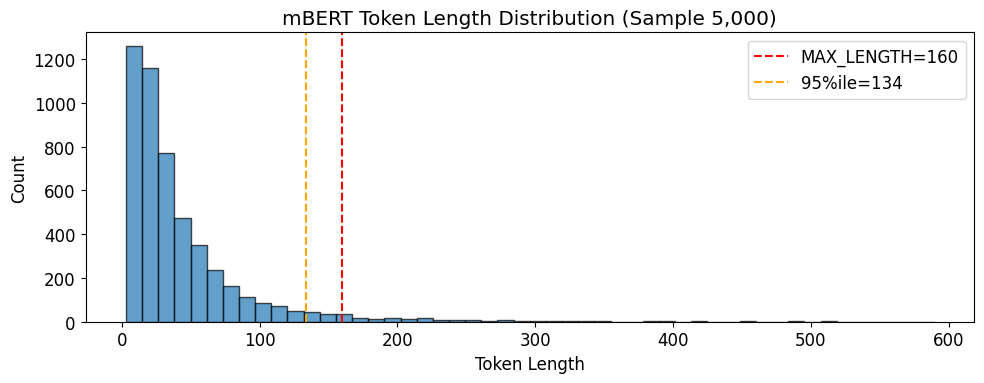

In [15]:
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

# 토큰 길이 분포 확인
sample_texts = train_df['clean_review'].sample(5000, random_state=42)
token_lengths = [len(tokenizer.encode(t, add_special_tokens=True)) for t in sample_texts]

p50 = int(np.percentile(token_lengths, 50))
p90 = int(np.percentile(token_lengths, 90))
p95 = int(np.percentile(token_lengths, 95))
p99 = int(np.percentile(token_lengths, 99))

print(f"토큰 길이 분포:")
print(f"  50%ile: {p50} | 90%ile: {p90} | 95%ile: {p95} | 99%ile: {p99} | max: {max(token_lengths)}")

# 95퍼센타일을 32 단위로 올림
MAX_LENGTH = int(np.ceil(p95 / 32) * 32)
MAX_LENGTH = min(MAX_LENGTH, 512)
print(f"\n→ MAX_LENGTH = {MAX_LENGTH}")

# 시각화
plt.figure(figsize=(10, 4))
plt.hist(token_lengths, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(MAX_LENGTH, color='red', linestyle='--', label=f'MAX_LENGTH={MAX_LENGTH}')
plt.axvline(p95, color='orange', linestyle='--', label=f'95%ile={p95}')
plt.xlabel('Token Length')
plt.ylabel('Count')
plt.title('mBERT Token Length Distribution (Sample 5,000)')
plt.legend()
plt.tight_layout()
plt.show()


## STEP 6: PyTorch Dataset & 클래스 가중치


In [16]:
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Dataset 생성
train_dataset = ReviewDataset(train_df['clean_review'], train_df['label'], tokenizer, MAX_LENGTH)
val_dataset   = ReviewDataset(val_df['clean_review'],   val_df['label'],   tokenizer, MAX_LENGTH)
test_dataset  = ReviewDataset(test_df['clean_review'],  test_df['label'],  tokenizer, MAX_LENGTH)

# 확인
sample = train_dataset[0]
print(f"input_ids shape:      {sample['input_ids'].shape}")
print(f"attention_mask shape: {sample['attention_mask'].shape}")
print(f"label: {sample['labels']}")

# 클래스 가중치
weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=train_df['label'].values)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)
print(f"\n클래스 가중치: 부정={weights[0]:.4f}, 긍정={weights[1]:.4f}")


input_ids shape:      torch.Size([160])
attention_mask shape: torch.Size([160])
label: 1

클래스 가중치: 부정=2.0886, 긍정=0.6574


## STEP 7: 모델 & Trainer 설정


In [17]:
# 커스텀 Trainer (클래스 불균형 보정)
class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

# 평가 메트릭
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds, average='weighted'),
        'f1_macro': f1_score(labels, preds, average='macro'),
        'auc': roc_auc_score(labels, probs),
    }

# mBERT 모델 로드
model = BertForSequenceClassification.from_pretrained(
    'bert-base-multilingual-cased', num_labels=2
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"모델 파라미터: {total_params:,}")

# 학습 설정
training_args = TrainingArguments(
    output_dir='./mbert_checkpoints',

    # 에폭 & 배치
    num_train_epochs=3,
    per_device_train_batch_size=32,    # OOM → 16으로 바꾸고 gradient_accumulation_steps=2
    per_device_eval_batch_size=64,

    # 학습률
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,

    # 평가 & 저장
    eval_strategy='steps',
    eval_steps=500,
    save_strategy='steps',
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    # 성능 최적화
    fp16=True,
    dataloader_num_workers=2,
    gradient_accumulation_steps=1,

    # 로깅
    logging_dir='./logs',
    logging_steps=100,
    report_to='none',
)

total_steps = len(train_dataset) // training_args.per_device_train_batch_size * int(training_args.num_train_epochs)
print(f"\n에폭: {training_args.num_train_epochs} | 배치: {training_args.per_device_train_batch_size}")
print(f"학습률: {training_args.learning_rate} | 총 스텝: ~{total_steps:,}")
print(f"예상 소요: ~60~90분 (T4 GPU)")


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated

모델 파라미터: 177,854,978

에폭: 3 | 배치: 32
학습률: 2e-05 | 총 스텝: ~9,375
예상 소요: ~60~90분 (T4 GPU)


## STEP 8: 학습 실행

> T4 기준 약 60~90분 소요됩니다.  
> OOM 에러가 나면 위 셀에서 `per_device_train_batch_size=16`, `gradient_accumulation_steps=2`로 바꾸고 다시 실행하세요.


In [18]:
trainer = WeightedTrainer(
    class_weights=class_weights,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("학습 시작...")
print("-" * 60)
train_result = trainer.train()

print(f"\n학습 완료!")
print(f"  총 스텝: {train_result.global_step}")
print(f"  최종 Train Loss: {train_result.training_loss:.4f}")


학습 시작...
------------------------------------------------------------


Step,Training Loss,Validation Loss,Accuracy,F1,F1 Macro,Auc
500,0.308727,0.267898,0.878748,0.884467,0.849984,0.956764
1000,0.246888,0.223329,0.929230,0.930056,0.904628,0.973925
1500,0.217771,0.191662,0.930360,0.931766,0.907873,0.978587
2000,0.208927,0.182814,0.922591,0.925149,0.900617,0.979718
2500,0.182301,0.188060,0.945121,0.945149,0.924323,0.982602
3000,0.185417,0.173734,0.935110,0.936644,0.914823,0.982831
3500,0.154334,0.245499,0.942649,0.941757,0.918416,0.983131
4000,0.137997,0.180082,0.940831,0.942013,0.921687,0.984226


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


학습 완료!
  총 스텝: 4000
  최종 Train Loss: 0.2314


## STEP 9: 학습 곡선 시각화


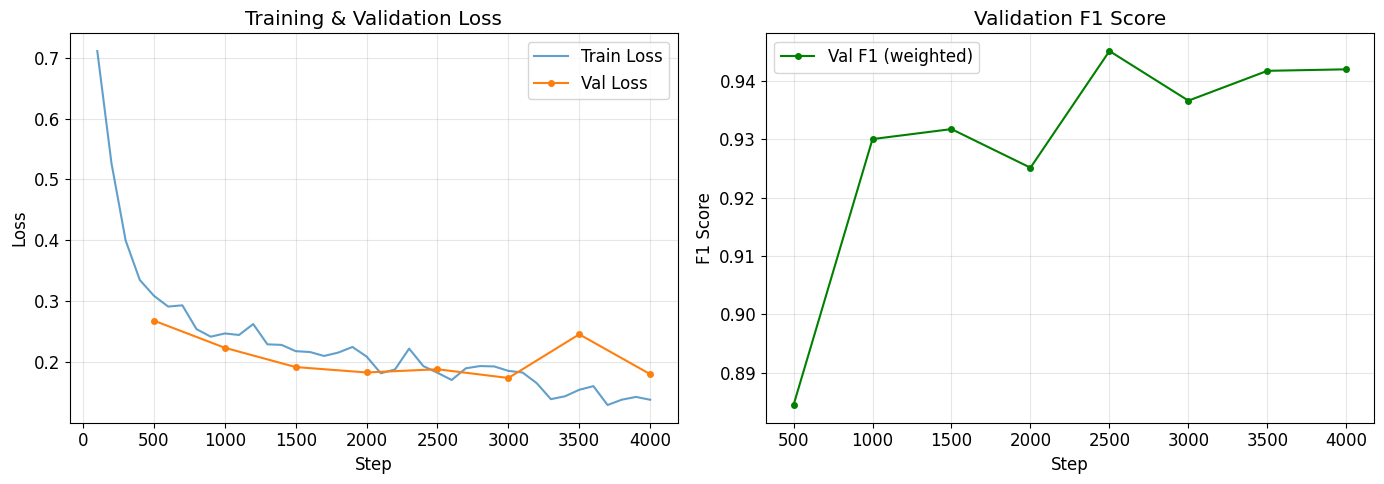

In [19]:
log_history = trainer.state.log_history

train_steps  = [x['step'] for x in log_history if 'loss' in x]
train_losses = [x['loss'] for x in log_history if 'loss' in x]
eval_steps   = [x['step'] for x in log_history if 'eval_loss' in x]
eval_losses  = [x['eval_loss'] for x in log_history if 'eval_loss' in x]
eval_f1s     = [x['eval_f1'] for x in log_history if 'eval_f1' in x]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_steps, train_losses, label='Train Loss', alpha=0.7)
axes[0].plot(eval_steps, eval_losses, label='Val Loss', marker='o', markersize=4)
axes[0].set_xlabel('Step')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_steps, eval_f1s, label='Val F1 (weighted)', marker='o', markersize=4, color='green')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## STEP 10: Test Set 최종 평가


In [20]:
predictions = trainer.predict(test_dataset)
logits = predictions.predictions
labels_true = predictions.label_ids
preds = np.argmax(logits, axis=-1)
probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

# Classification Report
print("[ Classification Report ]\n")
print(classification_report(
    labels_true, preds,
    target_names=['Negative (0)', 'Positive (1)'],
    digits=4
))

test_acc  = accuracy_score(labels_true, preds)
test_f1_w = f1_score(labels_true, preds, average='weighted')
test_f1_m = f1_score(labels_true, preds, average='macro')
test_auc  = roc_auc_score(labels_true, probs)

print(f"Accuracy:       {test_acc:.4f}")
print(f"F1 (weighted):  {test_f1_w:.4f}")
print(f"F1 (macro):     {test_f1_m:.4f}")
print(f"AUC-ROC:        {test_auc:.4f}")


[ Classification Report ]

              precision    recall  f1-score   support

Negative (0)     0.8824    0.8902    0.8863     13111
Positive (1)     0.9675    0.9649    0.9662     44330

    accuracy                         0.9479     57441
   macro avg     0.9249    0.9276    0.9263     57441
weighted avg     0.9480    0.9479    0.9480     57441

Accuracy:       0.9479
F1 (weighted):  0.9480
F1 (macro):     0.9263
AUC-ROC:        0.9830


## STEP 11: Confusion Matrix & ROC Curve


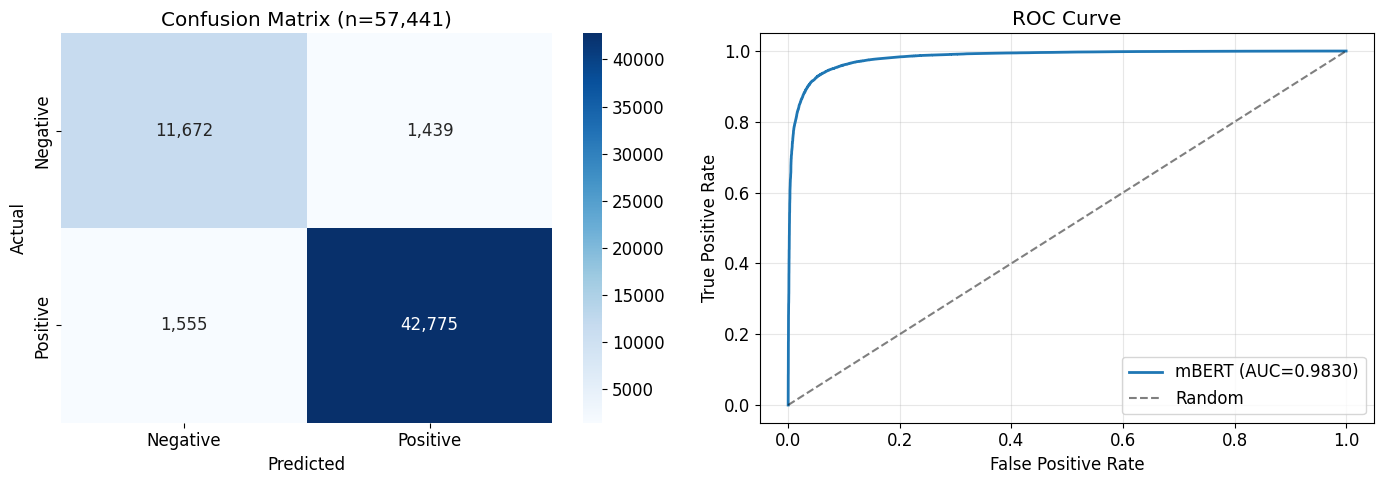

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(labels_true, preds)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'], ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (n={len(labels_true):,})')

fpr, tpr, _ = roc_curve(labels_true, probs)
axes[1].plot(fpr, tpr, label=f'mBERT (AUC={test_auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## STEP 12: 오분류 분석


In [22]:
test_results = test_df.reset_index(drop=True).copy()
test_results['pred'] = preds
test_results['prob_positive'] = probs
test_results['correct'] = (test_results['label'] == test_results['pred'])

errors = test_results[~test_results['correct']]
print(f"총 오분류: {len(errors):,}건 / {len(test_results):,}건 ({len(errors)/len(test_results):.1%})")

fp = errors[(errors['label'] == 0) & (errors['pred'] == 1)]
fn = errors[(errors['label'] == 1) & (errors['pred'] == 0)]
print(f"  False Positive (부정→긍정): {len(fp):,}건")
print(f"  False Negative (긍정→부정): {len(fn):,}건")

print(f"\n[ 확신하며 틀린 False Positive Top 5 ]")
for i, (_, row) in enumerate(fp.sort_values('prob_positive', ascending=False).head(5).iterrows()):
    print(f"  {i+1}. (conf={row['prob_positive']:.3f}) {row['clean_review'][:120]}...")

print(f"\n[ 확신하며 틀린 False Negative Top 5 ]")
for i, (_, row) in enumerate(fn.sort_values('prob_positive', ascending=True).head(5).iterrows()):
    print(f"  {i+1}. (conf={1-row['prob_positive']:.3f}) {row['clean_review'][:120]}...")


총 오분류: 2,994건 / 57,441건 (5.2%)
  False Positive (부정→긍정): 1,439건
  False Negative (긍정→부정): 1,555건

[ 확신하며 틀린 False Positive Top 5 ]
  1. (conf=0.996) wife loves this one...
  2. (conf=0.996) love this cover up...
  3. (conf=0.996) nice scent...
  4. (conf=0.996) love it looks better than in the pictures shipping was good...
  5. (conf=0.996) is soap its really good its the best...

[ 확신하며 틀린 False Negative Top 5 ]
  1. (conf=0.994) these are not durable i recently purchased these and have worn a hole in yet the third pouch i would not recommend these...
  2. (conf=0.993) crap dont waste your money it is literal junk the nail drill bits fall out when youre trying to use it its not worth it ...
  3. (conf=0.993) doesnt stay on longer than 2 days wouldnt buy again...
  4. (conf=0.993) the product shows no improvement whatsoever its a waste of money...
  5. (conf=0.993) i did not like the fact that i wasnt notified or given the option to to accept the smaller version or cancel giving me a..

## STEP 13: 모델 저장 (Google Drive 백업)


In [23]:
# 로컬 저장
MODEL_DIR = './mbert_sentiment_model'
trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)
print(f"모델 저장: {MODEL_DIR}")

# Drive 백업 (★ 경로 수정)
DRIVE_MODEL_DIR = '/content/drive/MyDrive/BeautyBridge/models/mbert_sentiment'
!mkdir -p {DRIVE_MODEL_DIR}
!cp -r {MODEL_DIR}/* {DRIVE_MODEL_DIR}/
print(f"Drive 백업: {DRIVE_MODEL_DIR}")

# 학습 로그 & 메트릭 저장
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(f'{DRIVE_MODEL_DIR}/training_log.csv', index=False)

test_metrics = {
    'accuracy': test_acc, 'f1_weighted': test_f1_w,
    'f1_macro': test_f1_m, 'auc_roc': test_auc,
    'sample_size': SAMPLE_SIZE, 'max_length': MAX_LENGTH,
    'epochs': training_args.num_train_epochs,
    'learning_rate': training_args.learning_rate,
    'batch_size': training_args.per_device_train_batch_size,
}
pd.DataFrame([test_metrics]).to_csv(f'{DRIVE_MODEL_DIR}/test_metrics.csv', index=False)
print("로그 & 메트릭 저장 완료")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

모델 저장: ./mbert_sentiment_model
Drive 백업: /content/drive/MyDrive/BeautyBridge/models/mbert_sentiment
로그 & 메트릭 저장 완료


## STEP 14: 추론 함수 (Streamlit 연동용)


In [24]:
def predict_sentiment(text, model, tokenizer, device, max_length):
    model.eval()
    encoding = tokenizer(
        text, max_length=max_length,
        padding='max_length', truncation=True, return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred].item()

    return {
        'label': 'positive' if pred == 1 else 'negative',
        'confidence': round(confidence, 4),
        'prob_negative': round(probs[0][0].item(), 4),
        'prob_positive': round(probs[0][1].item(), 4),
    }

# 테스트
test_cases = [
    "this sunscreen is amazing no white cast at all love it",
    "terrible product broke me out in hives would not recommend",
    "its okay nothing special for the price",
    "best moisturizer ive ever used my skin feels so smooth",
    "smells awful and left my skin feeling greasy",
]

print("[ 추론 테스트 ]\n")
for text in test_cases:
    result = predict_sentiment(text, model, tokenizer, device, MAX_LENGTH)
    emoji = "+" if result['label'] == 'positive' else "-"
    print(f"  [{emoji}] {result['label']:8s} (conf={result['confidence']:.3f}) | {text[:60]}")


[ 추론 테스트 ]

  [+] positive (conf=0.994) | this sunscreen is amazing no white cast at all love it
  [-] negative (conf=0.993) | terrible product broke me out in hives would not recommend
  [-] negative (conf=0.683) | its okay nothing special for the price
  [+] positive (conf=0.996) | best moisturizer ive ever used my skin feels so smooth
  [-] negative (conf=0.991) | smells awful and left my skin feeling greasy


## STEP 15: 전체 데이터 감성 점수 부여 (Fit Score 피처)

> 전체 589,308건에 대해 sentiment_score를 부여합니다.  
> 약 15~30분 소요됩니다.


전체 데이터: 589,308건
감성 점수 부여 중...

    25,600 / 589,308 (4%)
    51,200 / 589,308 (9%)
    76,800 / 589,308 (13%)
   102,400 / 589,308 (17%)
   128,000 / 589,308 (22%)
   153,600 / 589,308 (26%)
   179,200 / 589,308 (30%)
   204,800 / 589,308 (35%)
   230,400 / 589,308 (39%)
   256,000 / 589,308 (43%)
   281,600 / 589,308 (48%)
   307,200 / 589,308 (52%)
   332,800 / 589,308 (56%)
   358,400 / 589,308 (61%)
   384,000 / 589,308 (65%)
   409,600 / 589,308 (70%)
   435,200 / 589,308 (74%)
   460,800 / 589,308 (78%)
   486,400 / 589,308 (83%)
   512,000 / 589,308 (87%)
   537,600 / 589,308 (91%)
   563,200 / 589,308 (96%)
   588,800 / 589,308 (100%)

[ 감성 점수 분포 ]
  평균: 0.7516
  중위값: 0.9863
  원본 label 일치율: 94.8%

저장 완료: /content/drive/MyDrive/BeautyBridge/data/beauty_reviews_with_sentiment.csv


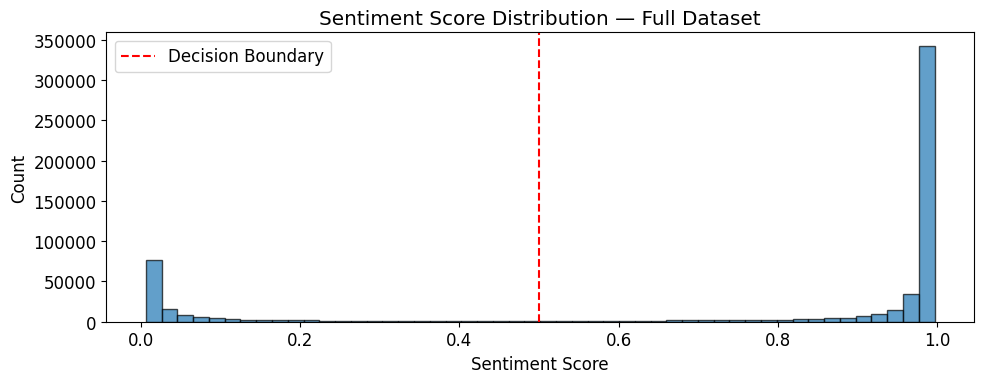

In [25]:
df_full = pd.read_csv(CSV_PATH)
df_full = df_full.dropna(subset=['clean_review'])
print(f"전체 데이터: {len(df_full):,}건")
print("감성 점수 부여 중...\n")

full_dataset = ReviewDataset(
    df_full['clean_review'],
    df_full['label'].astype(int),
    tokenizer, MAX_LENGTH
)
full_loader = DataLoader(full_dataset, batch_size=128, shuffle=False, num_workers=2)

all_preds = []
all_probs = []
model.eval()

with torch.no_grad():
    for i, batch in enumerate(full_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

        if (i + 1) % 200 == 0:
            done = min((i + 1) * 128, len(df_full))
            print(f"  {done:>8,} / {len(df_full):,} ({done/len(df_full):.0%})")

df_full['sentiment_pred'] = all_preds
df_full['sentiment_score'] = np.round(all_probs, 4)

print(f"\n[ 감성 점수 분포 ]")
print(f"  평균: {df_full['sentiment_score'].mean():.4f}")
print(f"  중위값: {df_full['sentiment_score'].median():.4f}")
print(f"  원본 label 일치율: {(df_full['label'].astype(int) == df_full['sentiment_pred']).mean():.1%}")

# 저장 (★ 경로 수정)
OUTPUT_PATH = '/content/drive/MyDrive/BeautyBridge/data/beauty_reviews_with_sentiment.csv'
df_full.to_csv(OUTPUT_PATH, index=False)
print(f"\n저장 완료: {OUTPUT_PATH}")

# 분포 시각화
plt.figure(figsize=(10, 4))
plt.hist(df_full['sentiment_score'], bins=50, edgecolor='black', alpha=0.7)
plt.axvline(0.5, color='red', linestyle='--', label='Decision Boundary')
plt.xlabel('Sentiment Score')
plt.ylabel('Count')
plt.title('Sentiment Score Distribution — Full Dataset')
plt.legend()
plt.tight_layout()
plt.show()


## 완료!

### 출력 파일
| 파일 | 위치 |
|---|---|
| 학습된 mBERT 모델 | `Drive/BeautyBridge/models/mbert_sentiment/` |
| 학습 로그 | `training_log.csv` |
| 테스트 메트릭 | `test_metrics.csv` |
| 전체 리뷰 + sentiment_score | `beauty_reviews_with_sentiment.csv` |

### 다음 단계
- `sentiment_score` (0~1)를 Category Fit Score의 **'현지 리뷰 감성 점수 30%'** 가중치 피처로 사용
- `product_id`별 평균 `sentiment_score` 집계 후 카테고리별 비교


In [26]:
# 확신도 구간별 정확도 확인 (Calibration)
bins = [0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 1.0]
df_full['score_bin'] = pd.cut(df_full['sentiment_score'], bins=bins)
df_full['correct'] = (df_full['label'].astype(int) == df_full['sentiment_pred'])

calibration = df_full.groupby('score_bin').agg(
    count=('correct', 'size'),
    accuracy=('correct', 'mean'),
    avg_confidence=('sentiment_score', 'mean')
).round(4)
print(calibration)

              count  accuracy  avg_confidence
score_bin                                    
(0.0, 0.2]   123133    0.9296          0.0361
(0.2, 0.4]    12196    0.6205          0.2912
(0.4, 0.6]    11101    0.5381          0.5048
(0.6, 0.8]    17642    0.7124          0.7115
(0.8, 0.9]    18763    0.8450          0.8565
(0.9, 0.95]   23647    0.9275          0.9291
(0.95, 1.0]  382826    0.9940          0.9892
